In [2]:
import os
import sys

import mudata
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from qmplot import qqplot

import os
import sys
import yaml
import logging
import mudata as mu
import pandas as pd
import cnmf
import scanpy as sc

# Change path to wherever you have repo locally
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/cNMF_benchmarking/cNMF_benchmarking_pipeline')

from Evaluation.src import (
    compute_perturbation_association,
)


# Compute real perturbation test

In [28]:
# IO path
out_dir = "/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Results"
run_name = "111025_D0_IGVF_10iter_torch_halsvar_batch_e7_v100s_test"

# resourse path
mdata_guide_path = "/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Cell_data/IGVF_D0_example.h5mu"
guide_annotation_path = "/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Data/guide/guide_metadata_v43.tsv"
reference_gtf_path="/oak/stanford/groups/engreitz/Users/opushkar/genome/IGVFFI9573KOZR.gtf.gz"

# data path
mdata_guide_path = "/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Data/IGVF_D0_example.h5mu"

# keys 
data_key = 'rna'
prog_key = "cNMF"
categorical_key="Day"
organism = "human"

# run variables
components = [30, 50, 60, 80, 100, 200]
sel_threshs = [0.4, 0.8, 2.0]
sample = ['1', '2', '3']

In [5]:
df_target = pd.read_csv(guide_annotation_path, sep = "\t", index_col = 0)
df_target_non = df_target[df_target["targeting"]==False]
reference_targets = df_target_non.index.values.tolist()

In [13]:
# reformat if needed 
mdata_guide = mu.read(mdata_guide_path)

# helper method 
def _assign_guide(mdata, mdata_guide):
        mdata['rna'].var_names = mdata['rna'].var['symbol']
        mdata['rna'].var['gene_names'] = mdata['rna'].var['symbol']
        mdata['cNMF'].uns['guide_names'] = mdata_guide['guide'].var['guide_id']
        mdata['cNMF'].uns['guide_targets'] = mdata_guide['guide'].var['intended_target_name']
        mdata['cNMF'].obsm['guide_assignment'] = mdata_guide['guide'].layers['guide_assignment'].toarray()
        mdata['rna'].obs[categorical_key] = "Day0"                                                                        


In [ ]:
for sel_thresh in sel_threshs:
    for k in components:  

        output_folder = f"{out_dir}/{run_name}/Eval/{k}_{str(sel_thresh).replace('.','_')}"

        os.makedirs(output_folder, exist_ok=True)

        # Load mdata
        mdata = mu.read('{out_dir}/{run_name}/adata/cNMF_{k}_{sel_thresh}.h5mu'.format(out_dir = out_dir,
                                                                                run_name =run_name,
                                                                                k=k,
                                                                                sel_thresh = str(sel_thresh).replace('.','_'))) 
                                                                      
        # assign guide
        _assign_guide(mdata, mdata_guide)   


        # Run perturbation assocation
        for samp in mdata['rna'].obs[categorical_key].unique():
            mdata_ = mdata[mdata['rna'].obs[categorical_key]==samp]
            test_stats_df = compute_perturbation_association(mdata_, prog_key=prog_key, 
                                                            collapse_targets=True,
                                                            pseudobulk=False,
                                                            reference_targets=reference_targets,
                                                            FDR_method = 'StoreyQ',
                                                            n_jobs=-1, inplace=False)

            test_stats_df.to_csv('{}/{}_perturbation_association_results_{}.txt'.format(output_folder,k,samp), sep='\t', index=False)

In [29]:
# if already have peturbation test data, read data 

test_stats_real_df = []

for sel_thresh in sel_threshs:
    for k in components:  
        for samp in sample:
            thresh_str = str(sel_thresh).replace('.', '_')
            test_stats_df_ = pd.read_csv(f'{out_dir}/{run_name}/Eval/{k}_{thresh_str}/{k}_perturbation_association_results_{samp}.txt', sep='\t')
            test_stats_df_['sample'] = samp
            test_stats_df_['K'] = k
            test_stats_df_['sel_thresh'] = sel_thresh
            #test_stats_df_['fdr'] = fdrcorrection(test_stats_df_['pval'])[1]
            test_stats_real_df.append(test_stats_df_)

# Concatenate AFTER all loops are done
test_stats_real_df = pd.concat(test_stats_real_df, ignore_index=True)
test_stats_real_df['real'] = True

# Compute fake perturbation test

In [31]:
# define variables
number_run = 10
number_guide = 6

In [36]:
# Load guide target
guide_annotation_path = "/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Data/guide/guide_metadata_v43.tsv"

guide_target = pd.read_csv(guide_annotation_path, sep='\t', index_col=0)
non_targeting_idx = guide_target.index[guide_target.targeting==False]  

guide_target = guide_target.loc[non_targeting_idx]

In [37]:
guide_target

,guide_names,spacer,targeting,targeting.1,guide_chr,guide_start,guide_end,strand,pam,guide_targets,intended_target_chr,intended_target_start,intended_target_end
1782,non-targeting_00014,GCCCTACATCGCTAGGCTA,False,non-targeting,NaN,NaN,NaN,NaN,NaN,non-targeting_00014,NaN,NaN,NaN
1783,non-targeting_00043,TACCAGCACGGAGCGGCAG,False,non-targeting,NaN,NaN,NaN,NaN,NaN,non-targeting_00043,NaN,NaN,NaN
1784,non-targeting_00117,AGCTCTTTGACGGACTGTG,False,non-targeting,NaN,NaN,NaN,NaN,NaN,non-targeting_00117,NaN,NaN,NaN
1785,non-targeting_00184,TCGGAGTAATGACCACAGC,False,non-targeting,NaN,NaN,NaN,NaN,NaN,non-targeting_00184,NaN,NaN,NaN
1786,non-targeting_00196,GAGATGTCCAGGCGTACAG,False,non-targeting,NaN,NaN,NaN,NaN,NaN,non-targeting_00196,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1910,SAFE_TARGETING_803,ACATCAGGTTCCTCTTAGA,False,non-targeting,NaN,NaN,NaN,NaN,NaN,SAFE_TARGETING_803,NaN,NaN,NaN
1911,SAFE_TARGETING_860,AGTTCCCCTTCTGCATATC,False,non-targeting,NaN,NaN,NaN,NaN,NaN,SAFE_TARGETING_860,NaN,NaN,NaN
1912,SAFE_TARGETING_878,AGAGCACTCAGCAAAATCA,False,non-targeting,NaN,NaN,NaN,NaN,NaN,SAFE_TARGETING_878,NaN,NaN,NaN
1913,SAFE_TARGETING_933,TTATGAACATGCTGTATGC,False,non-targeting,NaN,NaN,NaN,NaN,NaN,SAFE_TARGETING_933,NaN,NaN,NaN


In [33]:
# Calibrate tests using "fake_target guides"
test_stats_fake_dfs = []


for sel_thresh in sel_threshs:
    for k in components:  

        # Load mdata
        output_folder = f"{out_dir}/{run_name}/Eval/{k}_{str(sel_thresh).replace('.','_')}"
        os.makedirs(output_folder, exist_ok=True)
        mdata = mu.read('{out_dir}/{run_name}/adata/cNMF_{k}_{sel_thresh}.h5mu'.format(out_dir = out_dir,
                                                                                run_name =run_name,
                                                                                k=k,
                                                                                sel_thresh = str(sel_thresh).replace('.','_')))  

        # assign guide
        _assign_guide(mdata, mdata_guide) 


        for i in range(number_run):
            print(f"Running iteration {i+1}/{number_run} for {k} and {sel_thresh}")       

            # randomly make number_guide non-targeting guides targeting 
            guide_target_ = guide_target.copy()
            selected_guides = np.random.choice(guide_target_.guide_names, number_guide, replace=False)
            guide_target_.loc[guide_target_.guide_names.isin(selected_guides), 'targeting.1'] = 'targeting'
            
            '''
            # Filter to only non-targeting guides that exist in both datasets
            valid_guide_mask = np.isin(mdata['cNMF'].uns['guide_names'], guide_target_.guide_names.values)
            valid_indices = np.where(valid_guide_mask)[0]
            
            print(f"Found {len(valid_indices)} valid guides out of {len(mdata['cNMF'].uns['guide_names'])} total")
            
            if len(valid_indices) == 0:
                raise ValueError("No valid guides found")'''

            _mdata = mdata.copy()
            _mdata['cNMF'].obsm['guide_assignment'] = mdata['cNMF'].obsm['guide_assignment'][:, non_targeting_idx]
            _mdata['cNMF'].uns['guide_names'] = mdata['cNMF'].uns['guide_names'][non_targeting_idx]
            _mdata['cNMF'].uns['guide_targets'] = guide_target_.loc[guide_target_.guide_names.isin(mdata['cNMF'].uns['guide_names']), 'guide_targets'].values
            #_mdata['rna'].obs[categorical_key] = "Day0"


            # Run perturbation assocation
            for samp in _mdata['rna'].obs[categorical_key].unique():
                mdata_samp = _mdata[_mdata['rna'].obs[categorical_key]==samp]
                test_stats_df = compute_perturbation_association(mdata_samp, prog_key=prog_key, 
                                                                collapse_targets=True,
                                                                pseudobulk=False,
                                                                reference_targets=['non-targeting'],
                                                                FDR_method = 'BH',
                                                                n_jobs=-1, inplace=False)

                test_stats_df[categorical_key] = samp
                test_stats_df['K'] = k
                test_stats_df['run'] = i
                test_stats_df['sel_thresh'] = sel_thresh
                test_stats_fake_dfs.append(test_stats_df)

Running iteration 1/10 for 30 and 0.4
Found 119 valid guides out of 1923 total


/tmp/ipykernel_19593/3891929940.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  _mdata['cNMF'].uns['guide_names'] = mdata['cNMF'].uns['guide_names'][valid_indices]
Testing perturbation association:   0%|          | 0/114 [00:00<?, ?targets/s]/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/NMF_Benchmarking/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/NMF_Benchmarking/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/oak/stanford/groups/engreitz/Users/ymo/miniforge3/envs/NMF_Benchmarking/lib/python3.9/site-packages/anndata/_core/an

Running iteration 2/10 for 30 and 0.4
Found 119 valid guides out of 1923 total


KeyboardInterrupt: 

In [34]:
# Calibrate tests using "fake_target guides"
test_stats_fake_dfs = []

for i in range(number_run):

    for sel_thresh in sel_threshs:
        for k in components:  

            # randomly make 15 non-targeting guide targeting 
            guide_target_ = guide_target.copy()
            guide_target_.loc[guide_target_.guide_id.isin(np.random.choice(guide_target.guide_id, number_guide)), 'type'] = 'targeting'

    

            # Load mdata
            output_folder = f"{out_dir}/{run_name}/Eval/{k}_{str(sel_thresh).replace('.','_')}"
            os.makedirs(output_folder, exist_ok=True)
            mdata = mu.read('{out_dir}/{run_name}/adata/cNMF_{k}_{sel_thresh}.h5mu'.format(out_dir = out_dir,
                                                                                    run_name =run_name,
                                                                                    k=k,
                                                                                    sel_thresh = str(sel_thresh).replace('.','_')))                                                                   
            # assign guide
            _assign_guide(mdata, mdata_guide) 
            mdata['cNMF'].obsm['guide_assignment'] = mdata['cNMF'].obsm['guide_assignment'][:, non_targeting_idx]
            mdata['cNMF'].uns['guide_names'] = mdata['cNMF'].uns['guide_names'][non_targeting_idx]
            mdata['cNMF'].uns['guide_targets'] = guide_target_.loc[guide_target_.guide_id.isin(mdata['cNMF'].uns['guide_names']), 'type'].values
            
 
            # Run perturbation assocation
            for samp in mdata['rna'].obs[categorical_key].unique():
                mdata_ = mdata[mdata['rna'].obs[categorical_key]==samp]
                test_stats_df = compute_perturbation_association(mdata_, prog_key=prog_key, 
                                                                collapse_targets=True,
                                                                pseudobulk=False,
                                                                reference_targets='non-targeting',
                                                                FDR_method = 'storeyQ',
                                                                n_jobs=-1, inplace=False)

                test_stats_df[categorical_key] = samp
                test_stats_df['K'] = k
                test_stats_df['run'] = i
                test_stats_df['sel_thresh'] = sel_thresh
                test_stats_fake_dfs.append(test_stats_df)
                



AttributeError: 'DataFrame' object has no attribute 'guide_id'

In [18]:
# save fake test results
test_stats_fake_dfs = pd.concat(test_stats_fake_dfs)
test_stats_fake_dfs.to_csv('/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Data/perturbation_association_calibration.txt', sep='\t', index=False)

In [15]:
# if already have peturbation test data, read data 
test_stats_fake_dfs = pd.read_csv('/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Data/perturbation_association_calibration.txt', sep='\t')

# Compare 

In [16]:
# Merge
test_stats_fake_dfs['real'] = False
test_stats_dfs = pd.concat([test_stats_real_df, test_stats_fake_dfs])

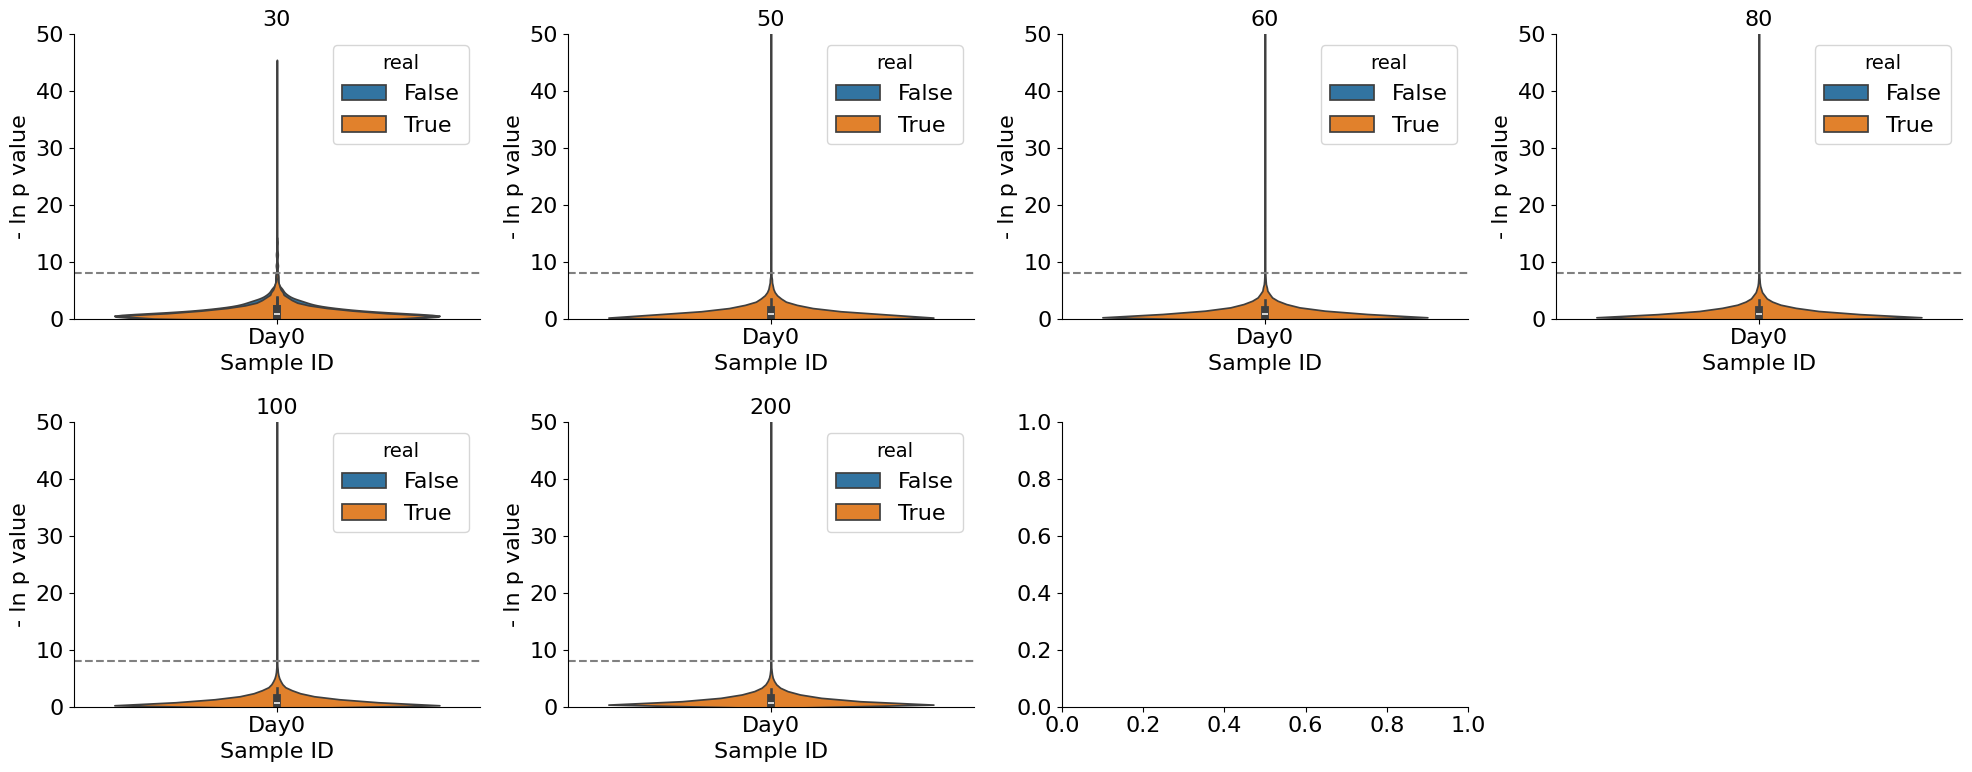

In [20]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20,8))
for i,k in enumerate(components):

    test_stats_dfs['neg_log_pval'] = test_stats_dfs['pval'].apply(lambda x: -np.log(x))
    sns.violinplot(x='sample', y='neg_log_pval', hue='real', data=test_stats_dfs.loc[test_stats_dfs.K==k], ax=axs.flat[i])
    axs.flat[i].set_title(str(k))
    axs.flat[i].set_xlabel('Sample ID')
    axs.flat[i].set_ylabel('- ln p value')
    axs.flat[i].set_ylim(0,50)
    axs.flat[i].axhline(8, color='grey', linestyle='dashed')

axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig('perturbation_association_calibration.png', dpi=100)

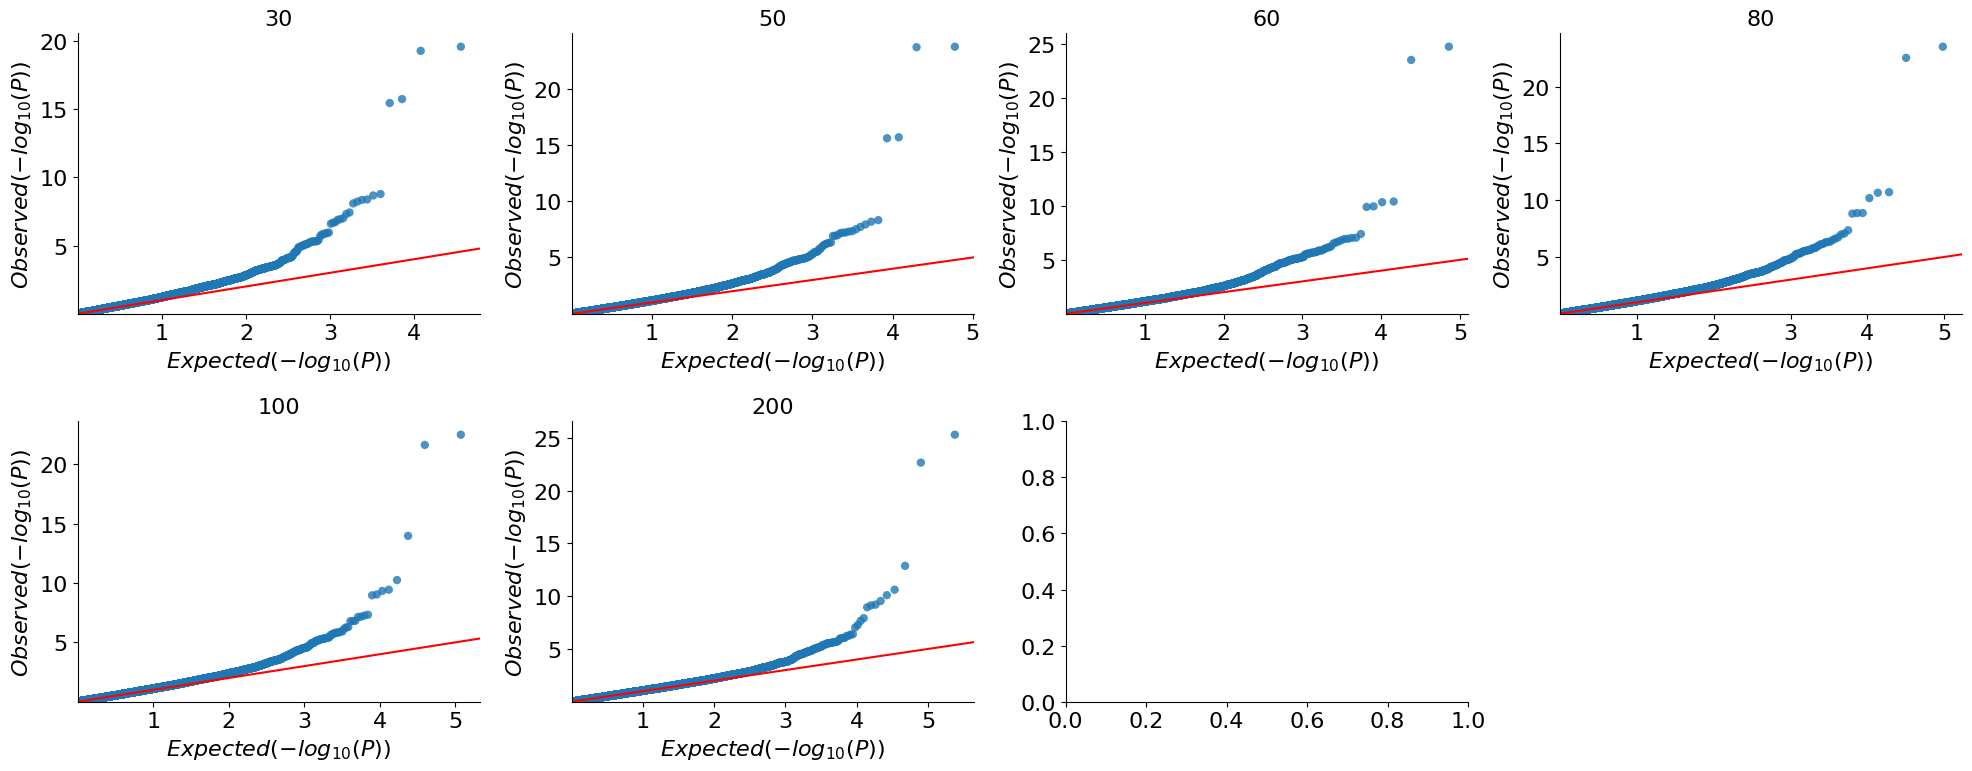

In [21]:
# QQ plot real
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20,8))
for i,k in enumerate(components):

    qqplot(data=test_stats_dfs.loc[(test_stats_dfs.K==k) & (test_stats_dfs.real==True), 'pval'], ax=axs.flat[i])
    axs.flat[i].set_title(str(k))

axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig('"/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Results/111025_D0_IGVF_10iter_torch_halsvar_batch_e7_v100s_test/Plot/Perturbation_calibration"/perturbation_association_qqplot_real.png', dpi=100)

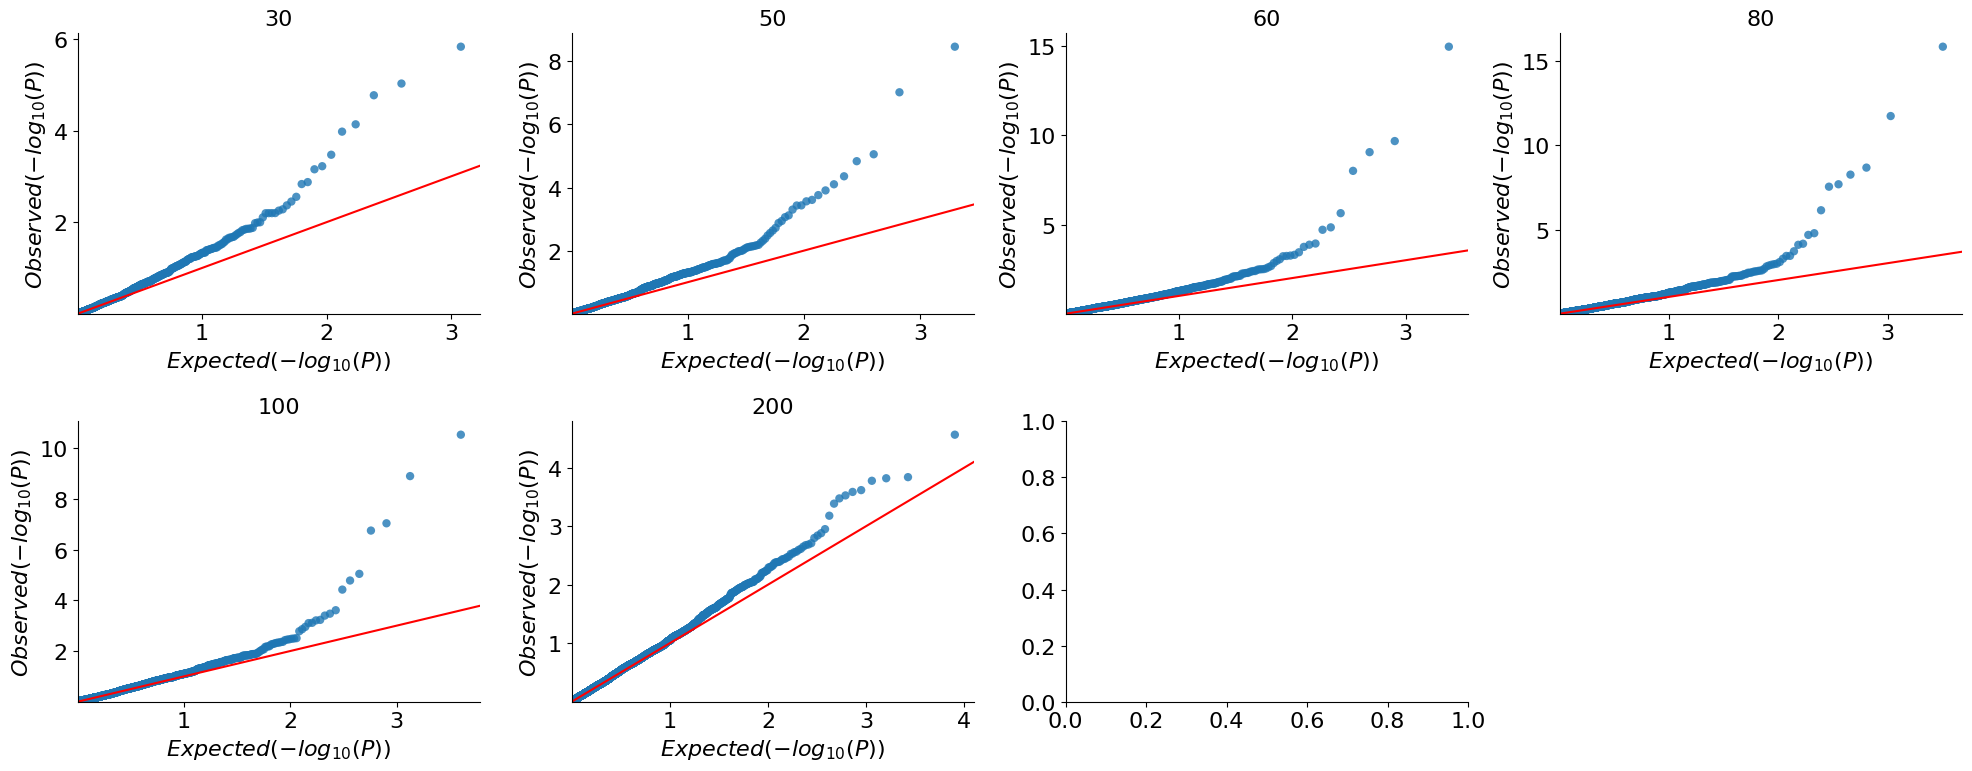

In [22]:
 # QQ plot fake
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20,8))
for i,k in enumerate(components):

    qqplot(data=test_stats_dfs.loc[(test_stats_dfs.K==k) & (not test_stats_dfs.real)& (test_stats_dfs.target_name=='targeting'), 'pval'], ax=axs.flat[i])
    axs.flat[i].set_title(str(k))

axs.flat[-1].axis('off')
plt.tight_layout()

plt.savefig('"/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Results/111025_D0_IGVF_10iter_torch_halsvar_batch_e7_v100s_test/Plot/Perturbation_calibration"/perturbation_association_qqplot_null.png', dpi=100)

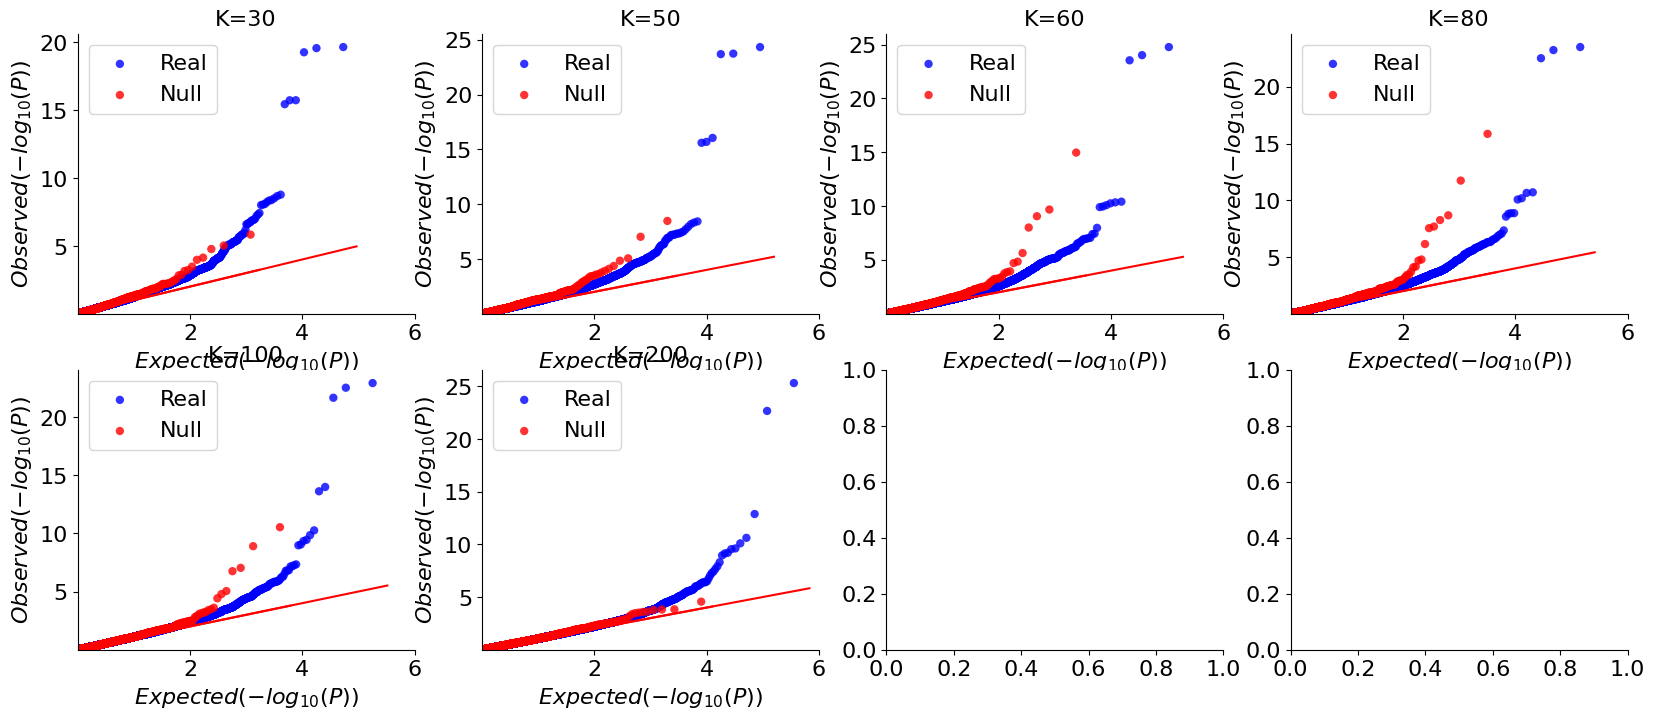

In [27]:
# combine 

fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20, 8))

for i, k in enumerate(components):
    ax = axs.flat[i]
    
    # Get data for both real and null
    real_pvals = test_stats_dfs.loc[(test_stats_dfs.K == k) & (test_stats_dfs.real == True), 'pval']
    null_pvals = test_stats_dfs.loc[(test_stats_dfs.K == k) & (test_stats_dfs.real == False) & (test_stats_dfs.target_name == 'targeting'), 'pval']
    
    # Real data
    qqplot(
        data=real_pvals,
        ax=ax,
        color='blue',
        label='Real'
    )
    
    # Null data
    qqplot(
        data=null_pvals,
        ax=ax,
        color='red',
        label='Null'
    )
    
    # Get current axis limits (after both plots are drawn)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Expand limits independently to include all data from both axes
    max_x = max(xlim[1], ylim[0])
    min_x = min(xlim[0], ylim[0])
    max_y = max(xlim[1], ylim[1])
    min_y = min(xlim[0], ylim[0])
    
    ax.set_xlim(min_x, 6)
    ax.set_ylim(min_y, max_y)
    
    ax.set_title(f'K={k}')
    ax.legend()

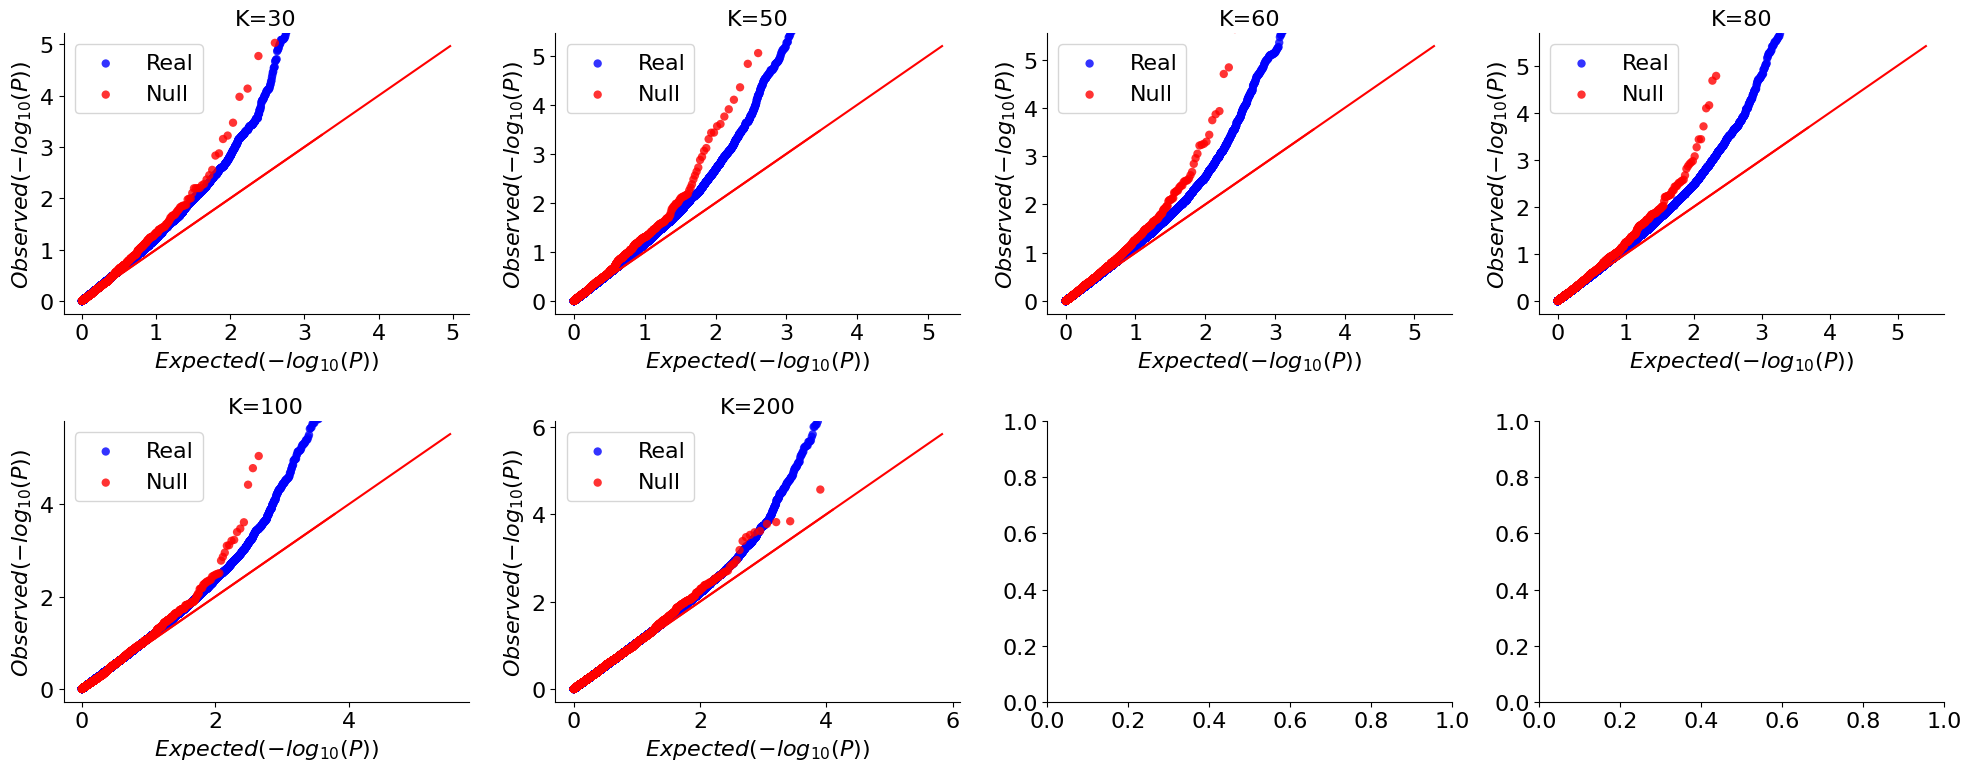

In [17]:
# combine 

fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20, 8))

for i, k in enumerate(components):
    ax = axs.flat[i]
    
    # Real data
    qqplot(
        data=test_stats_dfs.loc[(test_stats_dfs.K == k) & (test_stats_dfs.real == True), 'pval'],
        ax=ax,
        color='blue',
        label='Real'
    )
    
    # Null data
    qqplot(
        data=test_stats_dfs.loc[(test_stats_dfs.K == k) & (test_stats_dfs.real == False) & (test_stats_dfs.target_name == 'targeting'), 'pval'],
        ax=ax,
        color='red',
        label='Null'
    )
    
    ax.set_title(f'K={k}')
    ax.legend()
    
    # After getting all_x and all_y
    lines = ax.get_lines()
    all_x = np.concatenate([line.get_xdata() for line in lines])
    all_y = np.concatenate([line.get_ydata() for line in lines])
    padding = 0.05

    x_range = all_x.max() - all_x.min()
    y_range = all_y.max() - all_y.min()
    ax.set_xlim(all_x.min() - padding * x_range, all_x.max() + padding * x_range)
    ax.set_ylim(all_y.min() - padding * y_range, all_y.max() + padding * y_range)
        
    ax.set_title(f'K={k}')
    plt.tight_layout()
    ax.legend()
#plt.savefig('/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Results/111025_D0_IGVF_10iter_torch_halsvar_batch_e7_v100s_test/Plot/perturbation_association_qqplot_overlap.png', dpi=100)